# Thyroid nodule cytology classification (benign vs malignant)

Fine-tunes an ImageNet-pretrained GoogLeNet on a 328-image dataset I built from the Papanicolaou Society of Cytopathology atlas (196 malignant, 132 benign).

**Note:** the stored outputs were produced in 2021 with an earlier version of `confusion_metrics`, where *precision* was computed as TN/(TN+FP) (i.e. specificity). The code below has been corrected to TP/(TP+FP); see the README for the recomputed values. The images are not included in this repository.


In [ ]:
#GPU count and name
!nvidia-smi -L
from google.colab import output
!pip install ipython-autotime
%load_ext autotime
output.clear()

In [ ]:
# Imports
import torch
import torch.nn as nn  
import torch.optim as optim 
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms 
import torchvision
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn import metrics
import pandas as pd
from skimage import io
from tqdm import tqdm
from torch.utils.data import (
    Dataset,
    DataLoader,
)

# unzip data
from google.colab import drive
drive.mount('/content/drive')
!mkdir Tmp
!mkdir Tmp/Thyroid
!unzip drive/My\ Drive/Thyroid/Thyroid.zip -d Tmp/Thyroid
!mkdir Data
!mkdir Data/Thyroid
!mv Tmp/Thyroid/* Data/Thyroid/
!rm -r Tmp
output.clear()

time: 4.73 s (started: 2021-07-09 10:51:38 +00:00)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
num_classes = 2
learning_rate = 1e-3
batch_size = 32
validation_size = 0.1
num_epochs = 50

# Model
model = torchvision.models.googlenet(pretrained=True)
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

time: 213 ms (started: 2021-07-09 10:51:46 +00:00)


## Data

In [ ]:
class ThyroidDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        img_path = os.path.join(self.root_dir, self.annotations.iloc[index, 0])
        image = io.imread(img_path)
        y_label = torch.tensor(int(self.annotations.iloc[index, 1]))

        #transform
        if self.transform:
            image = self.transform(image)

        return (image, y_label)

time: 10.2 ms (started: 2021-07-09 10:51:48 +00:00)


In [ ]:
torch.manual_seed(3)
np.random.seed(3)

# Load Data
dataset = ThyroidDataset(
    csv_file="/content/drive/My Drive/Thyroid/assigned_classes.csv",
    root_dir="/content/Data/Thyroid"
)

test_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(size=(512, 512)),
                transforms.ToTensor()])

train_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(size=(512, 512)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(degrees=180),
                transforms.ColorJitter(brightness=0.1, contrast=0.2, saturation=0, hue=0),
                transforms.ToTensor()])

train_data, test_data = torch.utils.data.random_split(dataset, [299, 29], generator=torch.Generator().manual_seed(3))


# train_data to train and validation:
indices = list(range(len(train_data)))

np.random.shuffle(indices)
split = int(np.floor(validation_size * len(train_data)))
train_index, validation_index = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_index)
validation_sampler = SubsetRandomSampler(validation_index)

# loaders
temp_train = train_data
temp_train.dataset.transform = test_transform
validation_loader = torch.utils.data.DataLoader(temp_train,
                                                batch_size=batch_size,
                                                sampler=validation_sampler)

train_data.dataset.transform = train_transform
train_loader = torch.utils.data.DataLoader(train_data,
                                           batch_size=batch_size,
                                           sampler=train_sampler)

test_data.dataset.transform = test_transform
test_loader = torch.utils.data.DataLoader(test_data,
                                          batch_size=batch_size)

time: 31.2 ms (started: 2021-07-09 10:51:53 +00:00)


## Train

In [ ]:
# Creating a function to report confusion metrics
def confusion_metrics (conf_matrix, d_type='val'):
    TP = conf_matrix[1][1]
    TN = conf_matrix[0][0]
    FP = conf_matrix[0][1]
    FN = conf_matrix[1][0]
    
    # calculate accuracy
    conf_accuracy = (float (TP+TN) / float(TP + TN + FP + FN))
    

    if d_type == 'test':
        # calculate mis-classification
        conf_misclassification = 1- conf_accuracy
        
        # calculate the sensitivity
        conf_sensitivity = (TP / float(TP + FN))
        # calculate the specificity
        conf_specificity = (TN / float(TN + FP))
        
        # calculate precision
        conf_precision = (TP / float(TP + FP))
        # calculate f_1 score
        conf_f1 = 2 * ((conf_precision * conf_sensitivity) / (conf_precision + conf_sensitivity))
        print('True Positives:', TP)
        print('True Negatives:', TN)
        print('False Positives:', FP)
        print('False Negatives:', FN)
        print('-'*50)
        print(f'Accuracy: {round(conf_accuracy,2)}') 
        print(f'Mis-Classification: {round(conf_misclassification,2)}') 
        print(f'Sensitivity: {round(conf_sensitivity,2)}') 
        print(f'Specificity: {round(conf_specificity,2)}') 
        print(f'Precision: {round(conf_precision,2)}')
        print(f'f_1 Score: {round(conf_f1,2)}')
    return conf_accuracy

time: 16.2 ms (started: 2021-07-09 10:51:56 +00:00)


In [ ]:
def standard_train(model, t_loader, v_loader, criterion, optimizer, scheduler=None, device='cuda:0',
          epochs=100, verbose=1, checkpoint=20, checkpoint_name='model'):
    model.train()
    
    log_train_loss = []
    log_val_loss = []
    log_val_score = []
    best_score = 0
    for epoch in tqdm(range(epochs)):
        train_loss = 0
        train_n = 0

        # TRAINING LOOP
        for train_batch in t_loader:
            x, y = train_batch
            x, y = x.to(device), y.to(device)

            outputs = model(x).to(device)
            loss = criterion(outputs, y)

            train_loss += loss.item() * y.size(0)
            train_n += y.size(0)

            loss.backward()
            optimizer.step()
            if scheduler:
                scheduler.step()
            optimizer.zero_grad()

        train_loss = train_loss / train_n

        log = '\r{}\ntrain_loss:{:.4f}\n'.format(epoch + 1, train_loss)

        val_loss, val_score = evaluate(model, v_loader, criterion, device, 'val')
        if val_score >= best_score:
          torch.save(model.state_dict(), 'best.pt')
          best_score = val_score
        log += '  val_loss:{:.4f}\tval_score:{:.4f}\n'.format(val_loss, val_score)

        log_train_loss.append(train_loss)
        log_val_loss.append(val_loss)
        log_val_score.append(val_score)

        if (epoch + 1) % verbose == 0:
            print(log)

        if (epoch + 1) % checkpoint == 0:
            torch.save(model.state_dict(), f'{checkpoint_name}_epoch{epoch+1}.pth')
            print("Checkpoint", epoch+1, "saved!")

    return log_train_loss, log_val_loss, log_val_score

def evaluate(model, loader, criterion, device, d_type):
    model.eval()
    num_correct = 0
    num_samples = 0
    
    # VALIDATION LOOP
    with torch.no_grad():
        val_loss = 0
        val_score = 0
        val_n = 0
        conf_matrix = 0
        for val_batch in loader:
            x, y = val_batch
            # plt.imshow(transforms.ToPILImage()(x[1, :, :, :].to('cpu')), interpolation="bicubic")
            x, y = x.to(device), y.to(device)
            outputs = model(x).to(device)
            
            loss = criterion(outputs, y).item()
            _, predictions = outputs.max(1)
            # num_correct += (predictions == y).sum()
            # num_samples += predictions.size(0)
            
            val_loss += loss * y.size(0)
            # val_score += score * y.size(0)
            val_n += y.size(0)
            conf_matrix += metrics.confusion_matrix(y.cpu(), predictions.cpu())
            

        val_score = confusion_metrics(conf_matrix, d_type)

        # score = float(num_correct)/float(num_samples)*100
        val_loss = val_loss / val_n
        # val_score = val_score / val_n
        
    model.train()
    
    return val_loss, val_score

time: 74.7 ms (started: 2021-07-09 10:51:58 +00:00)


In [ ]:
log_train_loss, log_val_loss, log_val_score = standard_train(model.to(device), train_loader , validation_loader, criterion, optimizer,
                                                                            scheduler=None, device=device, epochs=num_epochs, 
                                                                            verbose=1, checkpoint=10, 
                                                                            checkpoint_name='google_net')

# Results

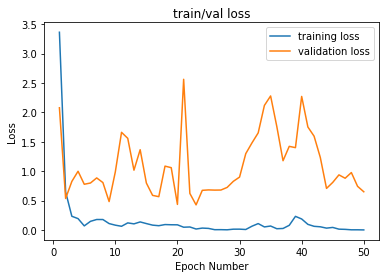

time: 170 ms (started: 2021-07-09 11:03:02 +00:00)


In [ ]:
plt.plot(range(1, num_epochs+1), log_train_loss, color='C0', label="training loss")
plt.plot(range(1, num_epochs+1), log_val_loss, color='C1', label="validation loss")
plt.legend()
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.title("train/val loss")
plt.show()

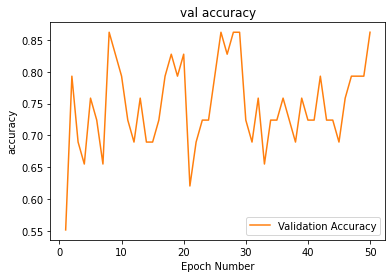

time: 144 ms (started: 2021-07-09 11:03:02 +00:00)


In [ ]:
plt.plot(range(1, num_epochs+1), log_val_score, color='C1', label='Validation Accuracy')
plt.legend()
plt.xlabel('Epoch Number')
plt.ylabel('accuracy')
plt.title("val accuracy")
plt.show()

In [ ]:
state_dict = torch.load('best.pt')
model.load_state_dict(state_dict)

<All keys matched successfully>

time: 77.7 ms (started: 2021-07-09 11:03:03 +00:00)


In [ ]:
val_loss, val_score = evaluate(model, validation_loader, criterion, device, 'test')
# print("Validation accuracy: {:.4f}".format(val_score))
print('Maximum validation accuracy epoch: ', np.argmax(log_val_score)+1)

True Positives: 14
True Negatives: 11
False Positives: 2
False Negatives: 2
--------------------------------------------------
Accuracy: 0.86
Mis-Classification: 0.14
Sensitivity: 0.88
Specificity: 0.85
Precision: 0.85
f_1 Score: 0.86
Maximum validation accuracy epoch:  8
time: 1.06 s (started: 2021-07-09 11:03:03 +00:00)


In [ ]:
test_loss, test_score = evaluate(model.to(device), test_loader, criterion, device, 'test')

True Positives: 20
True Negatives: 7
False Positives: 2
False Negatives: 0
--------------------------------------------------
Accuracy: 0.93
Mis-Classification: 0.07
Sensitivity: 1.0
Specificity: 0.78
Precision: 0.78
f_1 Score: 0.88
time: 961 ms (started: 2021-07-09 11:03:04 +00:00)
